In [11]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [12]:
words = open('names.txt', 'r').read().splitlines()

In [13]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


# MLP character-level language model

In [14]:
# first build the dataset
block_size = 3 # context length (how many characters to predict the next one)
X, Y = [], []

for w in words:
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
n = X.nelement() / block_size
print(X.shape)
print(n)

torch.Size([228146, 3])
228146.0


In [15]:
C = torch.randn((27, 2)) # 2D embedding space
emb = C[X] # more efficient than one-hot encoding but does the same thing
emb.shape

torch.Size([228146, 3, 2])

In [16]:
W1 = torch.randn((6, 100)) # 6 = 3 context length * 2D emb space, 100 is hyperparam
b1 = torch.randn(100)

# need to make the emb (n inputs)x6 so concat the context length dimension using unbind
# torch.cat(torch.unbind(emb, 1), 1)
# actually much more efficient to just view the emb tensor as a nx6 rather than
# making a new tnensor as torch stores tensors as a 1D array so can easily rearrange
# we can either set n manually of torch can infer the correct n (228146) if
# set it to -1

h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

torch.Size([228146, 100])

In [17]:
W2 = torch.randn((100, 27)) # 100 because of last layer, 27 for unemb
b2 = torch.randn(27)

In [18]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [20]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(int(n)), Y].log().mean()
print(loss.item())

17.827423095703125


In [21]:
# --- tidying it up a bit ---
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g) # 2D embedding space
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
params = [C, W1, b1, W2, b2]
for p in params:
  p.requires_grad = True

In [22]:
print(f'total params: {sum(p.nelement() for p in params)}')

total params: 3481


In [23]:
LR = 0.1

for _ in range(10000):
  # Doing GD for the whole dataset is inefficient so we only do this for mini batches (of 32 here)
  ix = torch.randint(0, X.shape[0], (32,))

  # forward pass
  emb = C[X[ix]]
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2
  # now use torch implementation of loss calc which is much more efficient and more robust to large logits in logits.exp()
  # (does this by using negative logits only as shifting all logits by a fixed value gives the same final prob but won't overflow in the exp term)
  loss = F.cross_entropy(logits, Y[ix])

  # backward pass
  for p in params:
    p.grad = None
  loss.backward()

  # update
  for p in params:
    p.data += - LR * p.grad

print(loss.item())


1.9909623861312866


In [24]:
# overall loss (as opposed to loss just for the mini-batch)
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss.item()

2.5261905193328857

### MLP with splits

In [25]:
# training split (train params, 80%), dev/validation split (train hyperparams, 10%), test split (10%)
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 0-80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 80-90%
Xte, Yte = build_dataset(words[n2:]) # 90-100%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [26]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g) # 2D embedding space
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
params = [C, W1, b1, W2, b2]
for p in params:
  p.requires_grad = True

print(f'total params: {sum(p.nelement() for p in params)}')

total params: 11897


In [27]:
stepi = []
lossi = []

trn loss: 1.6370152235031128


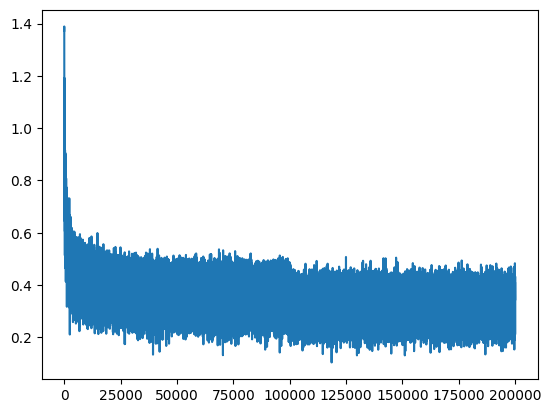

In [28]:
# train only on the training data Xtr, Ytr

for i in range(200000):
  # mini batch
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in params:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # a slightly decaying lr
  for p in params:
    p.data += - lr * p.grad

  # track stats
  stepi.append(i)
  lossi.append(loss.log10().item())

print(f'trn loss: {loss.item()}')
plt.plot(stepi, lossi)


In [29]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.1685168743133545

In [30]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
aar.
hari.
kemri.
reety.
halayane.
rahuel.
deliah.
jareen.
ner.
kearceriiy.
kaleigh.
ham.
joce.
quintis.
lilea.
jadia.
wavero.
dearynix.
kael.
